<a href="https://colab.research.google.com/github/Son-jinseon/adot-voice-feedback/blob/main/adot_voice_feedback.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 에이닷(A.) 음성인식 및 AI 요약 피드백 분석 보고서

## 📌 프로젝트 개요
* **프로젝트명:** SKT 에이닷(A.) 앱 리뷰 데이터 기반 NLU/AI 피드백 분석
* **목적:** 에이닷 앱의 Google Play Store 리뷰 데이터를 수집·분석하여, 핵심 서비스인 NLU(음성인식, STT, AI 통화 요약)에 대한 사용자 불편 사항(Pain Point)을 파악하고 개선 방향 도출
* **데이터:** Google Play Store 'MOST_RELEVANT' 기준 에이닷 앱 리뷰 500건
* **주요 분석 파이프라인:**
  1. 리뷰 수집 및 한글 텍스트 전처리
  2. Okt 형태소 분석기를 활용한 명사 추출 및 빈도 분석
  3. 키워드 기반 카테고리 분류 (NLU, System, Feature, General)
  4. NLU 영역 불만 사항(Pain Point) 세부 분류 및 시각화

In [70]:
# !pip install google-play-scraper pandas matplotlib seaborn
# !pip install konlpy
# !pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 23.2 MB/s eta 0:00:00


In [71]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
from konlpy.tag import Okt
from google_play_scraper import Sort, reviews
from collections import Counter

In [4]:
# 에이닷 어플 리뷰 관련도 높은 순 500건 수집
app_id = 'com.skt.nugu.apollo'

result, _ = reviews(
    app_id,
    lang='ko',
    country='kr',
    sort=Sort.MOST_RELEVANT,
    count=500
    )

In [5]:
df = pd.DataFrame(result)

df.shape

(500, 11)

In [6]:
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,16361845-4a5a-4153-86dc-b4343ca3d914,ᅵᅳ,https://play-lh.googleusercontent.com/a/ACg8oc...,녹음 자체는 잘 됩니다 강의 랑 말소리가 같이 들리면 둘 다 잡히네요 다글로?디글로...,5,12,4.3.5,2026-05-30 14:07:27,안녕하세요. 에이닷 팀입니다.\n\n노트 서비스 이용 시 녹음 중 잡음이 포함되면 ...,2026-06-01 09:25:58,4.3.5
1,6a5402a5-7a1b-4dbf-8008-3aa2a73edd01,Ga Na,https://play-lh.googleusercontent.com/a-/ALV-U...,안녕하세요 전에 로그인이 안된다고 리뷰 남겼던 사람입니다 덕분에 로그인은 잘 됐는데...,5,12,4.4.2,2026-07-07 09:19:02,안녕하세요. 에이닷 팀 입니다.\n에이닷 서비스 이용에 감사드립니다.\n\n에이닷 ...,2026-07-09 04:33:48,4.4.2
2,4fcdad81-196f-4cb8-add1-c2c7ec70bc6a,김태민,https://play-lh.googleusercontent.com/a/ACg8oc...,통화요약이 되는건 좋습니다. 녹음은 혹시 모르는 상황에 대비하여 자동녹음을 하는것인...,3,24,None,2026-04-08 23:48:26,안녕하세요. 에이닷 팀입니다.\n\n[에이닷 전화]와 [에이닷]앱은 별개의 앱으로\...,2026-04-15 08:47:02,None
3,5fff52bd-96a3-4c83-afa1-29bd98fd75c3,김연범,https://play-lh.googleusercontent.com/a/ACg8oc...,오늘 업데이트 이후 수신전화는 에이닷으로 연결되어 자동관리 되는데 T전화를 통해 송...,3,372,2.8.0,2024-04-01 07:08:03,안녕하세요 A.(에이닷) 운영센터입니다.\n\nA.서비스 이용에 감사드립니다.\n\...,2024-04-01 07:29:44,2.8.0
4,9b789f4d-4ecf-48ea-bdf0-95b2c90b8330,정민주,https://play-lh.googleusercontent.com/a/ACg8oc...,루틴을 관리하기에 좋아서 이 앱을 사용하고 있어요! 정말 유용합니답!! --그런데 ...,5,115,None,2024-03-16 13:39:09,안녕하세요 A.(에이닷) 운영센터입니다.\n\nA. 서비스를 이용해 주셔서 감사합니...,2024-03-18 00:14:47,None


---

In [8]:
# 텍스트 정제 함수
def clean_text(text):
    if not isinstance(text, str):
        return ""

    cleaned = re.sub(r'[^가-힣\s]', ' ', text)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()

    return cleaned

In [11]:
df['clean_content'] = df['content'].apply(clean_text)

In [13]:
display(df[['content', 'clean_content']].head())
display(df[['content', 'clean_content']].tail())

,content,clean_content
0,녹음 자체는 잘 됩니다 강의 랑 말소리가 같이 들리면 둘 다 잡히네요 다글로?디글로...,녹음 자체는 잘 됩니다 강의 랑 말소리가 같이 들리면 둘 다 잡히네요 다글로 디글로...
1,안녕하세요 전에 로그인이 안된다고 리뷰 남겼던 사람입니다 덕분에 로그인은 잘 됐는데...,안녕하세요 전에 로그인이 안된다고 리뷰 남겼던 사람입니다 덕분에 로그인은 잘 됐는데...
2,통화요약이 되는건 좋습니다. 녹음은 혹시 모르는 상황에 대비하여 자동녹음을 하는것인...,통화요약이 되는건 좋습니다 녹음은 혹시 모르는 상황에 대비하여 자동녹음을 하는것인데...
3,오늘 업데이트 이후 수신전화는 에이닷으로 연결되어 자동관리 되는데 T전화를 통해 송...,오늘 업데이트 이후 수신전화는 에이닷으로 연결되어 자동관리 되는데 전화를 통해 송신...
4,루틴을 관리하기에 좋아서 이 앱을 사용하고 있어요! 정말 유용합니답!! --그런데 ...,루틴을 관리하기에 좋아서 이 앱을 사용하고 있어요 정말 유용합니답 그런데 두 가지 ...


,content,clean_content
495,상품개발 제대로 안하실겁니까? 올해들어 첫 댓글이자 화가 심하게 나는 케이스네요. ...,상품개발 제대로 안하실겁니까 올해들어 첫 댓글이자 화가 심하게 나는 케이스네요 업데...
496,1. 에이닷 전화에서 영상통화 버튼이 안 보입니다. 시인성 개선을 부탁 드립니다. ...,에이닷 전화에서 영상통화 버튼이 안 보입니다 시인성 개선을 부탁 드립니다 에이닷 전...
497,안드로이드오토 사용자는 전화벨이 안울림. 시스템끼리 충돌하는지 뭔지 운전하면서 전화...,안드로이드오토 사용자는 전화벨이 안울림 시스템끼리 충돌하는지 뭔지 운전하면서 전화수...
498,프렌즈 캐릭터 중 육제이 사용 언어중에 헐 개 이런 비속어 사용이 많습니다. 미취학...,프렌즈 캐릭터 중 육제이 사용 언어중에 헐 개 이런 비속어 사용이 많습니다 미취학 ...
499,skt 이용자만 더 불편해진 어플. 타통신사 쓰는사람은 전화는 기본어플 그대로 쓰고...,이용자만 더 불편해진 어플 타통신사 쓰는사람은 전화는 기본어플 그대로 쓰고 통화녹음...


In [21]:
(df['clean_content'].str.strip() != '').value_counts()

,count
clean_content,
True,500


---

In [23]:
# df['clean_content'][0]

'녹음 자체는 잘 됩니다 강의 랑 말소리가 같이 들리면 둘 다 잡히네요 다글로 디글로 에서는 딱 걸러서 받아쓰기 가 되던데 아쉽네요 그리고 시험퀴즈나 도 내용 정리해주면 좋을 것 같습니다 강의노트에서 혼자 저절로 숫자가 있는 부분에는 중간에 줄이 쫙 쳐서 나옵니다 그리고 영어로 예를들어 유브이오 라고 하는데 한국발음으로 적용됩니다 그런데 전화녹음이랑 녹음이 합쳐서 분이네요 너무 짧은것 같습니다'

In [27]:
# print(okt.nouns(df['clean_content'][0]))

['녹음', '자체', '강의', '말소리', '둘', '글', '디글', '받아쓰기', '시험', '퀴즈', '도', '내용', '정리', '것', '강의', '노트', '혼자', '저절로', '숫자', '부분', '중간', '쫙', '영어', '예', '유', '브이', '오', '한국', '발음', '적용', '전화', '녹음', '녹음']


In [28]:
okt = Okt()

nouns = []
for text in df['clean_content']:
    for noun in okt.nouns(text):
        if len(noun) >= 2:
            nouns.append(noun)

In [32]:
noun_df = pd.DataFrame(Counter(nouns).items(), columns=['명사', '빈도수']).sort_values(by='빈도수', ascending=False).reset_index(drop=True)

noun_df.head(30) # 단어의 빈도만으로 긍정인지 부정인지 알 수 없음

,명사,빈도수
0,전화,829
1,통화,534
2,에이,418
3,기능,337
4,사용,302
5,요약,223
6,녹음,195
7,업데이트,128
8,어플,122
9,기존,94


### 📌 단어 빈도 분석 주요 특징

1. **'전화/통화 (녹음·요약)' 언급 압도적**
   - `전화`(829), `통화`(534), `요약`(223), `녹음`(195)이 상위권 집중
   - 단순 AI 대화보다 **'통화 녹음/STT/AI 요약'** 유저 경험의 핵심 영역

2. **업데이트 관련 단어 출연**
   - `업데이트`(128), `기존`(94) 단어가 자주 나옴.
   - 업데이트 및 기존 버전과의 비교에 대한 유저 반응이 다수 존재

3. **분류 키워드 구성 기준 확보**
   - 빈도수 상위권 단어 중 실제 도메인 관련 단어를 선별하여 분류 기준 반영

---

### 📌 이슈 성격별 분류 체계 및 키워드 구성 기준

1. **카테고리 정의 기준 (이슈의 성격별 분류)**
   - `NLU/핵심기능`: AI 음성 인식, STT, 통화 요약 등 **AI 핵심 기술 및 결과물 품질** 관련 피드백
   - `System`: 앱 튕김, 로딩 지연, 업데이트 후 작동 불가 등 **앱 실행 및 시스템 안정성** 관련 피드백
   - `Feature`: UI/UX, 특정 기능 추가/삭제/개선 등 **제품 기능 범위 및 사용자 편의성** 관련 피드백

2. **키워드 선별 및 확장 기준**
   - **구어체/동사 표현 보강:** 명사 빈도 분석(Okt)에서 누락된 유저들의 불만 표현 동사/형용사(`못 알아`, `튕김`, `먹통` 등) 수동 추가
   - **도메인 유의어 그룹핑:** 동일한 문제 현상을 가리키는 다양한 유저 표현(예: `안돼`, `오류`, `먹통` -> System)을 카테고리별로 유의어 묶음화
   - **우선순위 적용:** AI 서비스 특성을 고려하여 핵심 기술 관련 언급(`NLU`)을 우선 감지하도록 조건문 순서 배치

In [33]:
# 리뷰 카테고리별 대표 키워드 리스트
nlu_keywords = ['전화', '통화', '요약', '녹음', '텍스트', '대화', '음성', '변환', '인식', '발음', '대답', '이해', '목소리', '딴소리', '잘못', '못 알아', '알아듣', '엉뚱']
system_keywords = ['업데이트', '기존', '화면', '오류', '먹통', '끊김', '안됨', '로딩', '렉', '버그', '연결', '멈춤', '튕김', '안돼']
feature_keywords = ['기능', '기록', '캐릭터', '삭제', '설정', '개선', '추가', '없어', '불편', '바꿔', '수정']

In [38]:
# 리뷰 분류 함수
def classify_review(text):

    if any(k in text for k in nlu_keywords):
        return 'NLU_음성인식/AI요약'
    elif any(k in text for k in system_keywords):
        return 'System_앱성능/안정성'
    elif any(k in text for k in feature_keywords):
        return 'Feature_기능/사용성'
    else:
        return 'General_일반의견'

In [40]:
df['issue_category'] = df['clean_content'].apply(classify_review)

In [44]:
category_counts = df['issue_category'].value_counts()
category_pcts = (df['issue_category'].value_counts(normalize=True) * 100).round(1)

summary_df = pd.DataFrame({
    '리뷰 건수(건)': category_counts,
    '비중(%)': category_pcts
})

summary_df

,리뷰 건수(건),비중(%)
issue_category,,
NLU_음성인식/AI요약,417,83.4
System_앱성능/안정성,33,6.6
Feature_기능/사용성,31,6.2
General_일반의견,19,3.8


In [67]:
summary_df.iloc[:,0]

,리뷰 건수(건)
issue_category,
NLU_음성인식/AI요약,417
System_앱성능/안정성,33
Feature_기능/사용성,31
General_일반의견,19


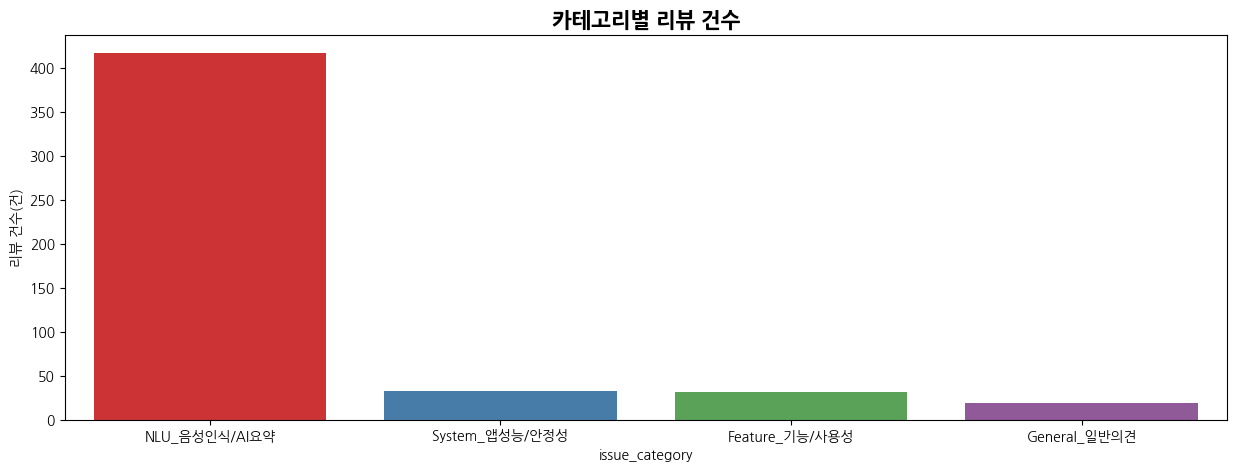

In [108]:
# 시각화
plt.figure(figsize=(15, 5))
sns.barplot(x=summary_df.index, y=summary_df.iloc[:, 0], data=summary_df, palette="Set1", hue=summary_df.index)

plt.title('카테고리별 리뷰 건수', fontsize=15, fontweight='bold')

plt.show()

### 📌 키워드 기반 카테고리 분류 결과

- **NLU_음성인식/AI요약 (83.4% / 417건):** 유저 언급의 압도적 다수가 통화 녹음, STT, AI 요약 및 대화 기능 영역에 집중
- **System_앱성능/안정성 (6.6% / 33건):** 업데이트, 로딩, 앱 실행 및 시스템 관련 언급
- **Feature_기능/사용성 (6.2% / 31건):** UI/UX, 캐릭터, 설정 및 편의 기능 관련 언급
- **General_일반의견 (3.8% / 19건):** 기타 짧은 의견 및 단발성 반응

> **💡 핵심 인사이트:**  
> 에이닷 이용 유저의 관심과 피드백은 대부분 `음성인식 및 AI 통화 요약 핵심 기술`에 집중되어 있으며, 해당 영역이 전체 유저 경험(UX) 품질을 결정하는 가장 중요한 요소임을 확인

---

In [85]:
# NLU_음성인식/AI요약 관련 부정 리뷰
nlu_df = df[df['issue_category'] == 'NLU_음성인식/AI요약'].copy()

pain_keywords = ['아쉽', '불만', '불편', '개선', '수정', '보완', '엉뚱', ' 이상', '바꿔', '근데', '하지만', '오류', '안됨', '안돼', '잘못', '못', '틀림']

nlu_df['has_pain_point'] = nlu_df['clean_content'].apply(lambda x: any(k in str(x) for k in pain_keywords))

pain_reviews = nlu_df[nlu_df['has_pain_point']].copy()

In [87]:
print(pain_reviews.shape)
pain_reviews.head()

(289, 14)


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,clean_content,issue_category,has_pain_point
0,16361845-4a5a-4153-86dc-b4343ca3d914,ᅵᅳ,https://play-lh.googleusercontent.com/a/ACg8oc...,녹음 자체는 잘 됩니다 강의 랑 말소리가 같이 들리면 둘 다 잡히네요 다글로?디글로...,5,12,4.3.5,2026-05-30 14:07:27,안녕하세요. 에이닷 팀입니다.\n\n노트 서비스 이용 시 녹음 중 잡음이 포함되면 ...,2026-06-01 09:25:58,4.3.5,녹음 자체는 잘 됩니다 강의 랑 말소리가 같이 들리면 둘 다 잡히네요 다글로 디글로...,NLU_음성인식/AI요약,True
2,4fcdad81-196f-4cb8-add1-c2c7ec70bc6a,김태민,https://play-lh.googleusercontent.com/a/ACg8oc...,통화요약이 되는건 좋습니다. 녹음은 혹시 모르는 상황에 대비하여 자동녹음을 하는것인...,3,24,None,2026-04-08 23:48:26,안녕하세요. 에이닷 팀입니다.\n\n[에이닷 전화]와 [에이닷]앱은 별개의 앱으로\...,2026-04-15 08:47:02,None,통화요약이 되는건 좋습니다 녹음은 혹시 모르는 상황에 대비하여 자동녹음을 하는것인데...,NLU_음성인식/AI요약,True
3,5fff52bd-96a3-4c83-afa1-29bd98fd75c3,김연범,https://play-lh.googleusercontent.com/a/ACg8oc...,오늘 업데이트 이후 수신전화는 에이닷으로 연결되어 자동관리 되는데 T전화를 통해 송...,3,372,2.8.0,2024-04-01 07:08:03,안녕하세요 A.(에이닷) 운영센터입니다.\n\nA.서비스 이용에 감사드립니다.\n\...,2024-04-01 07:29:44,2.8.0,오늘 업데이트 이후 수신전화는 에이닷으로 연결되어 자동관리 되는데 전화를 통해 송신...,NLU_음성인식/AI요약,True
5,21dac162-c543-4f52-98a5-8047ed15d572,Suny,https://play-lh.googleusercontent.com/a/ACg8oc...,통화요약은 완전 잘 쓰고 있습니다. 이 기능때메 설치했었어요 ㅎㅎ 전화기능도 업데이...,5,525,2.8.0,2024-04-02 09:25:13,안녕하세요 A.(에이닷) 운영센터입니다.\n\nA. 서비스에 관심을 갖고 소중한 의...,2024-04-03 00:06:51,2.8.0,통화요약은 완전 잘 쓰고 있습니다 이 기능때메 설치했었어요 전화기능도 업데이트 되었...,NLU_음성인식/AI요약,True
6,1d7ab6dd-1bb1-466f-a431-bd95d1444c48,Truth Kim,https://play-lh.googleusercontent.com/a-/ALV-U...,이미 생성형 AI를 다양하게 사용해본 사람으로써 아직까지는 제한적인 부분이 많았습니...,2,84,3.1.0,2024-10-17 07:33:40,안녕하세요 A.(에이닷) 운영센터입니다.\nA. 서비스에 관심을 갖고 소중한 제안을...,2024-10-17 08:21:36,3.1.0,이미 생성형 를 다양하게 사용해본 사람으로써 아직까지는 제한적인 부분이 많았습니다 ...,NLU_음성인식/AI요약,True


In [89]:
# 세부 문제 영역 분류
stt_keywords = ['받아쓰기', '변환', '발음', '글자', '오타', 'STT', '인식', '글']
summary_keywords = ['요약', '맥락', '핵심', '줄거리', '딴소리', '이해', '내용', '줄여']
audio_keywords = ['녹음', '마이크', '소리', '볼륨', '음성']

In [90]:
def classify_pain_detail(text):

    has_stt = any(k in text for k in stt_keywords)
    has_summary = any(k in text for k in summary_keywords)
    has_audio = any(k in text for k in audio_keywords)

    if has_stt and has_summary:
        return 'STT+AI 복합'
    elif has_stt:
        return 'STT 인식/변환'
    elif has_summary:
        return 'AI 요약/이해'
    elif has_audio:
        return '녹음/음성 품질'
    else:
        return '기타'

In [92]:
nlu_df['nlu_pain_detail'] = nlu_df['clean_content'].apply(classify_pain_detail)

In [97]:
nlu_df[['clean_content', 'nlu_pain_detail']]

,clean_content,nlu_pain_detail
0,녹음 자체는 잘 됩니다 강의 랑 말소리가 같이 들리면 둘 다 잡히네요 다글로 디글로...,STT+AI 복합
2,통화요약이 되는건 좋습니다 녹음은 혹시 모르는 상황에 대비하여 자동녹음을 하는것인데...,AI 요약/이해
3,오늘 업데이트 이후 수신전화는 에이닷으로 연결되어 자동관리 되는데 전화를 통해 송신...,AI 요약/이해
5,통화요약은 완전 잘 쓰고 있습니다 이 기능때메 설치했었어요 전화기능도 업데이트 되었...,AI 요약/이해
6,이미 생성형 를 다양하게 사용해본 사람으로써 아직까지는 제한적인 부분이 많았습니다 ...,기타
...,...,...
493,전화쓰다가 에이닷전화쓰니 기능이 너무 불편함 통화기록에서 클릭하면 상세하게 들어가는...,기타
496,에이닷 전화에서 영상통화 버튼이 안 보입니다 시인성 개선을 부탁 드립니다 에이닷 전...,기타
497,안드로이드오토 사용자는 전화벨이 안울림 시스템끼리 충돌하는지 뭔지 운전하면서 전화수...,AI 요약/이해
498,프렌즈 캐릭터 중 육제이 사용 언어중에 헐 개 이런 비속어 사용이 많습니다 미취학 ...,기타


In [107]:
nlu_summary = pd.DataFrame({
    '리뷰건수(건)': nlu_df['nlu_pain_detail'].value_counts(),
    '비중(%)': (nlu_df['nlu_pain_detail'].value_counts(normalize=True) * 100).round(1)
})

nlu_summary

,리뷰건수(건),비중(%)
nlu_pain_detail,,
AI 요약/이해,157,37.6
기타,129,30.9
녹음/음성 품질,58,13.9
STT+AI 복합,39,9.4
STT 인식/변환,34,8.2


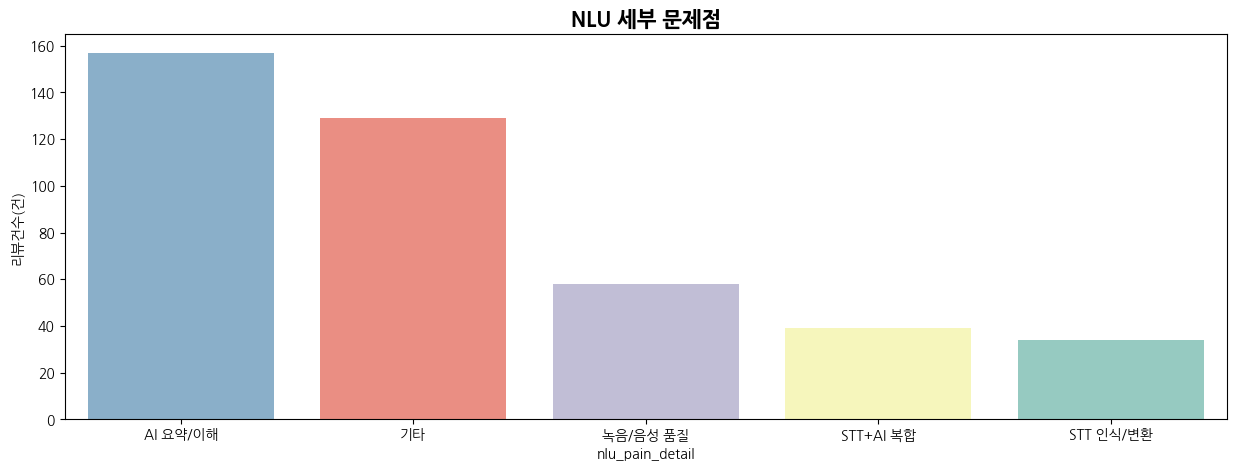

In [109]:
plt.figure(figsize=(15, 5))
sns.barplot(data=nlu_summary, x=nlu_summary.index, y='리뷰건수(건)', hue='리뷰건수(건)', palette='Set3', legend=False)

plt.title('NLU 세부 문제점', fontsize=15, fontweight='bold')
plt.show()

### 📌 NLU 세부 문제점 분석

- **AI 요약/이해 (157건, 37.6%):** 불만 유형 중 가장 높은 비중을 차지함. 대화 내용을 잘못 요약하거나 뜻을 이해하지 못하는 문제가 핵심 원인
- **기타 (129건, 30.9%):** 카테고리 외 일반 불만 사항.
- **녹음/음성 품질 (58건, 13.9%):** 음량 부족, 잡음 등 소리 자체의 품질 관련 문제
- **STT+AI 복합 (39건, 9.4%):** 음성 변환과 AI 이해 오류가 동시에 발생하는 경우
- **STT 인식/변환 (34건, 8.2%):** 말소리를 텍스트로 바꾸는 과정에서 생기는 인식 오류

---

### 📌 최종 결론 및 개선 방향

사용자 불만은 **AI의 요약 및 이해 능력 부족(37.6%)**에 가장 집중되어 있으며, 음성 인식 및 음질 관련 문제(합산 31.5%)가 뒤를 이음

1. **AI 요약 및 이해 모델 집중 개선:** 비중이 가장 큰 대화 요약 정확도와 맥락 이해 성능을 최우선 보완
2. **음성 인식(STT) 오류 감축:** 소음이나 불명확한 발음에도 글자로 잘 바뀔 수 있도록 인식 성능을 높임
3. **복합 오류 방지:** 인식 오류가 잘못된 AI 답변으로 이어지지 않도록 데이터 보정 절차를 마련